[ENG]

PROJECT 4: BAGGING, RANDOM FOREST, GRID SEARCH and HYPERPARAMETERS

[FR]

PROJET 4 : BAGGING, RANDOM FOREST, GRID SEARCH and HYPERPARAMETRES

[ENG]

EXERCISE 1 : BAGGING AGAINST RANDOM FORESTS


[FR] 

EXERCICE 1 : BAGGING CONTRE FORETS ALEATOIRES

[ENG]

1. Explain what is meant by the principle of bootstrapping and what is covered by bagging

[FR]

1. Expliquez ce que signifie le principe du bootstrapping et ce que recouvre le bagging

### Bootstrapping and Bagging

**Bootstrapping**, or *bootstrap sampling*, consists of randomly extracting a subset from the dataset and using it to train a decision tree. After training, the subset is returned to the dataset, and another subset is randomly extracted to train the next decision tree. The number of decision trees to train is determined when instantiating the Random Forest model.

Bootstrapping is a **resampling technique** that involves repeatedly drawing samples from the dataset **with replacement** — meaning an observation that was already chosen may be selected again. This technique is useful for estimating the **uncertainty** in performance metrics by simulating variability across different training samples.

---

**Bagging**, short for *Bootstrap Aggregating*, builds upon bootstrapping. It involves training multiple models using different bootstrapped samples of the original dataset, and then aggregating their predictions (e.g., by majority vote for classification or averaging for regression).

A limitation of Bagging is that **all features** are used for training each tree, without any feature selection. As a result, dominant numeric features can be repeatedly used across trees, potentially creating strong **correlation** between them. This can reduce the diversity of the ensemble and limit its ability to generalize compared to methods like Random Forest, which add further randomness by selecting a random subset of features at each split.
Key improvements:

In [1]:
# Packages
import pandas as pd
import numpy as np
import time

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, auc, precision_score, roc_auc_score , classification_report
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import GridSearchCV

[ENG]

2. Prepare the training data set with a 70/30 split

[FR]

2. Préparez le jeu de données d’entraînement avec un split 70/30

In [2]:
# Open dataset
indian_liver_df= pd.read_csv("C://Users//emmhu//OneDrive//Documents//E-LEARNING//DU DATA ANALYST//4_Introduction au ML supervisé//Données//Project_4_Liver//indian_liver_patient.csv")

indian_liver_df.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [3]:
# Discovering the dataset
indian_liver_df.shape

(583, 11)

In [4]:
# Discovering the dataset
print(indian_liver_df.info())
print(indian_liver_df.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB
None
               Age Gender  Total_Bilirubin  Direct_Bilirubin  \
count   583.000000    

In [5]:
# Check for missing data
print(indian_liver_df.isnull().sum())

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    4
Dataset                       0
dtype: int64


In [6]:
# Display rows with missing values
missing = indian_liver_df['Albumin_and_Globulin_Ratio'].isnull()

print(indian_liver_df[missing])  

     Age  Gender  Total_Bilirubin  Direct_Bilirubin  Alkaline_Phosphotase  \
209   45  Female              0.9               0.3                   189   
241   51    Male              0.8               0.2                   230   
253   35  Female              0.6               0.2                   180   
312   27    Male              1.3               0.6                   106   

     Alamine_Aminotransferase  Aspartate_Aminotransferase  Total_Protiens  \
209                        23                          33             6.6   
241                        24                          46             6.5   
253                        12                          15             5.2   
312                        25                          54             8.5   

     Albumin  Albumin_and_Globulin_Ratio  Dataset  
209      3.9                         NaN        1  
241      3.1                         NaN        1  
253      2.7                         NaN        2  
312      4.8        

In [7]:
# Convert 'Albumin_and_Globulin_Ratio' to numeric type for proper handling
indian_liver_df['Albumin_and_Globulin_Ratio'] = pd.to_numeric(indian_liver_df['Albumin_and_Globulin_Ratio'], errors='coerce')

# Impute missing values with the mean of the column
albu_glo_mean = indian_liver_df['Albumin_and_Globulin_Ratio'].mean()  # Calculate the mean
indian_liver_df['Albumin_and_Globulin_Ratio'].fillna(albu_glo_mean, inplace=True)

C:\Users\emmhu\AppData\Local\Temp\ipykernel_21488\2073536665.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  indian_liver_df['Albumin_and_Globulin_Ratio'].fillna(albu_glo_mean, inplace=True)


In [8]:
# No more missing values
print(indian_liver_df.isnull().sum())

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    0
Dataset                       0
dtype: int64


In [9]:
# Observing variables
print(indian_liver_df.columns)

Index(['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin',
       'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
       'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin',
       'Albumin_and_Globulin_Ratio', 'Dataset'],
      dtype='object')


In [10]:
# Select relevant columns and separate features (X) and target (y)

X= indian_liver_df[['Total_Bilirubin', 'Direct_Bilirubin',
       'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
       'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin',
       'Albumin_and_Globulin_Ratio','Age']]

y= indian_liver_df[['Gender']]

In [11]:
# Splitting the dataset between a training set (70 %) and a test set (30 %)
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.3, random_state=9)

In [12]:
# Feature Scaling 
scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


# If X is a DataFrame, preserve column names
if isinstance(X, pd.DataFrame):
    cols = X.columns  # Extract column names
    X_train = pd.DataFrame(X_train, columns=cols)
    X_test = pd.DataFrame(X_test, columns=cols)
else:
    # If X is not a DataFrame, generate column names
    cols = [f"Feature_{i}" for i in range(X.shape[1])]
    X_train = pd.DataFrame(X_train, columns=cols)
    X_test = pd.DataFrame(X_test, columns=cols)

# Display transformed data shapes for verification
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (408, 9)
X_test shape: (175, 9)


[ENG]

3. Using Python, use BaggingClassifier from sklearn.ensemble on a decision tree that you have instantiated. Train the model and calculate various performance metrics (accuracy, recall, AUC).

[FR]

3. Avec Python, utilisez BaggingClassifier de sklearn.ensemble sur un arbre de décision que vous aurez instancié. Entraînez le modèle, et calculez différentes métriques de performance (accuracy, recall, AUC)

In [13]:
# Instantiate a decision tree model
dt= DecisionTreeClassifier(min_samples_leaf= 6, random_state= 9)

In [14]:
# Instantiate BaggingClassifier
bc= BaggingClassifier(estimator= dt, n_estimators= 20, random_state=9)

In [15]:
# Fit bc to the training set
bc.fit(X_train, y_train)

c:\Users\emmhu\anaconda3\envs\Bac_a_sable\Lib\site-packages\sklearn\ensemble\_bagging.py:888: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


BaggingClassifier(estimator=DecisionTreeClassifier(min_samples_leaf=6,
                                                   random_state=9),
                  n_estimators=20, random_state=9)

In [16]:
# Predict test set labels
y_pred_bc= bc.predict(X_test)

In [17]:
# Evaluate accuracy
accuracy_bc= accuracy_score(y_test, y_pred_bc)

print(f'The accuracy score of bc is : {accuracy_bc:.2f}')

The accuracy score of bc is : 0.75


In [18]:
# Evaluate Recall
recall_bc = recall_score(y_test, y_pred_bc, pos_label='Male')

print(f'The recall score of bc is : {recall_bc:.2f}')


The recall score of bc is : 0.95


In [19]:
# Evaluate Precision
precision_bc= precision_score(y_test,y_pred_bc, pos_label='Male')

print(f'The precision score of bc is : {precision_bc:.2f}')

The precision score of bc is : 0.78


In [20]:
# Evaluate AUC
y_probs = bc.predict_proba(X_test)[:, 1]
auc_bc = roc_auc_score(y_test, y_probs)

print(f'The AUC score of bc is : {auc_bc:.2f}')

The AUC score of bc is : 0.65


### Model Evaluation Metrics

- **High Recall (0.95)**: The model is highly sensitive to the positive class (*Male*), meaning it correctly identifies 95% of actual Male instances. This suggests that very few Male samples are missed (low false negatives).

- **Moderate AUC (0.65)**: The Area Under the ROC Curve indicates that the model’s ability to distinguish between the classes is better than random, but not strong. This may suggest overlapping feature distributions between classes or a need for further model tuning or feature engineering.

- **Accuracy (0.76)**: The overall accuracy is 76%, which aligns fairly well with the high recall. However, if the dataset is imbalanced, accuracy may be misleading, as it can be dominated by the majority class.

- **Precision (0.78)**: When the model predicts 'Male', it is correct 78% of the time. This suggests a moderate rate of false positives (i.e., predicting Male when the instance is actually not Male).

[ENG]

4. Import and instantiate a random forest. Apply it to the training dataset, and then compare the performance metrics of the validation dataset with those of the previous mode

[FR]

4. Importez et instanciez une forêt aléatoire. Appliquez-la sur le jeu de données d’entraînement, et comparez ensuite sur le jeu de validation les métriques de performance avec celles du modèle précédent

In [21]:
# Instantiate Random Forest Classifier
rf= RandomForestClassifier(n_estimators= 20, random_state=10)

In [22]:
# Fit the model to the training set
rf.fit(X_train, y_train)

c:\Users\emmhu\anaconda3\envs\Bac_a_sable\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(n_estimators=20, random_state=10)

In [23]:
# Predict the test set label
y_pred_rf= rf.predict(X_test)

In [24]:
# Evaluate the model accuracy
accuracy_rf= accuracy_score(y_test, y_pred_rf)

print(f'The accuracy score of rf is : {accuracy_rf:.2f}')

The accuracy score of rf is : 0.75


In [25]:
# Evaluate Recall
recall_rf = recall_score(y_test, y_pred_rf, pos_label='Male')

print(f'The recall score of rf is : {recall_rf:.2f}')

The recall score of rf is : 0.92


In [26]:
# Evaluate Precision
precision_rf= precision_score(y_test,y_pred_rf, pos_label='Male')

print(f'The precision score of bc is : {precision_rf:.2f}')

The precision score of bc is : 0.78


In [27]:
# Evaluate AUC
y_probs_rf = rf.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_probs_rf)

print(f'The AUC score of rf is : {auc_rf:.2f}')

The AUC score of rf is : 0.66


In [28]:
# Comparing metrics performance

print('Metrics performance are :')
print(f"{'Metric':<15}{'Bagging Classifier':<20}{'Random Forest':<20}")
print(f"{'-'*55}")
print(f"{'Accuracy':<15}{accuracy_bc:<20.2f}{accuracy_rf:<20.2f}")
print(f"{'Recall':<15}{recall_bc:<20.2f}{recall_rf:<20.2f}")
print(f"{'Precision':<15}{precision_bc:<20.2f}{precision_rf:<20.2f}")
print(f"{'AUC':<15}{auc_bc:<20.2f}{auc_rf:<20.2f}")

Metrics performance are :
Metric         Bagging Classifier  Random Forest       
-------------------------------------------------------
Accuracy       0.75                0.75                
Recall         0.95                0.92                
Precision      0.78                0.78                
AUC            0.65                0.66                


### Model Comparison: Bagging Classifier vs. Random Forest

- **Accuracy**: The Bagging Classifier achieves an accuracy of 0.76, slightly outperforming the Random Forest model, which scores 0.75.

- **Recall**: Both models perform similarly in terms of recall, with scores of 0.93 for Bagging and 0.92 for Random Forest, indicating strong sensitivity to the positive class.

- **Precision**: Both classifiers yield the same precision score of 0.78, meaning that 78% of the predicted positive instances are correct.

- **AUC (Area Under the Curve)**: Both models exhibit moderate class separation ability, with AUC scores of 0.65 (Bagging) and 0.66 (Random Forest).

---

#### Understanding the Relationship Between Bagging and Random Forest

Random Forest is an enhancement of the Bagging method using decision trees. While Bagging builds multiple trees using bootstrap samples, it uses **all available features** when determining splits. In contrast, **Random Forest introduces additional randomness** by selecting only a random subset of features at each split. This reduces the chance of overfitting and decorrelates the trees.

Even with Bagging, decision trees can develop similar structures—especially when dominant features consistently influence the splits—leading to **high correlation** in predictions. Random Forest addresses this limitation by increasing tree diversity, thereby improving generalization and predictive performance.


[ENG]

5. Estimate the relative importance of the various features using rf.feature_importances , by creating a vector. To do this, use pd.Series in Python. After sorting in descending order, use a barplot to represent this vector of importance


[FR]

5. Estimez l’importance relative des différents features grâce à rf.feature_importances , en créant un vecteur. Pour ce faire, vous mobiliserez pd.Series en Python. Après un tri par ordre décroissant, représentez par un barplot ce vecteur d’importance.

In [29]:
# Use rf.feature_importances_ to know features importance
feature_scores = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

feature_scores

Total_Protiens                0.149429
Aspartate_Aminotransferase    0.136904
Age                           0.134589
Alkaline_Phosphotase          0.130243
Alamine_Aminotransferase      0.125131
Total_Bilirubin               0.109498
Albumin                       0.084648
Albumin_and_Globulin_Ratio    0.077081
Direct_Bilirubin              0.052476
dtype: float64

In [30]:
# Version 2 : Use rf.feature_importances_ to know features importance (PART 1)

# Ensure X is the list of feature names
if isinstance(X, pd.DataFrame):
    feature_names = X.columns.tolist()  # Extract feature names if X is a DataFrame
else:
    feature_names = [f"Feature_{i}" for i in range(X.shape[1])]  # Generate generic names if unavailable

# Verify the lengths match
assert len(feature_names) == len(rf.feature_importances_)  # if mismatch between feature names and importance

In [31]:
# To Get Features importance without using Feature Scaling (PART 2)

# Start timing
start_time = time.time()

# Extract feature importances
importances = rf.feature_importances_

# Use pd.Series for initial inspection
feature_importances_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)
print("\nFeature Importances (Series):")
print(feature_importances_series)

# Create DataFrame from the Series for better presentation
feature_imp_df = feature_importances_series.reset_index()
feature_imp_df.columns = ['Feature', 'Gini Importance']

# Display the feature importance DataFrame
print("\nFeature Importances (DataFrame):")
print(feature_imp_df)

elapsed_time= time.time() - start_time

print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")


Feature Importances (Series):
Total_Protiens                0.149429
Aspartate_Aminotransferase    0.136904
Age                           0.134589
Alkaline_Phosphotase          0.130243
Alamine_Aminotransferase      0.125131
Total_Bilirubin               0.109498
Albumin                       0.084648
Albumin_and_Globulin_Ratio    0.077081
Direct_Bilirubin              0.052476
dtype: float64

Feature Importances (DataFrame):
                      Feature  Gini Importance
0              Total_Protiens         0.149429
1  Aspartate_Aminotransferase         0.136904
2                         Age         0.134589
3        Alkaline_Phosphotase         0.130243
4    Alamine_Aminotransferase         0.125131
5             Total_Bilirubin         0.109498
6                     Albumin         0.084648
7  Albumin_and_Globulin_Ratio         0.077081
8            Direct_Bilirubin         0.052476
Elapsed time to compute the importances: 0.005 seconds


In [32]:
# Version 3 : Use rf.feature_importances_ to know features importance
start_time= time.time()

importances= rf.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Gini Importance': importances}).sort_values('Gini Importance', ascending=False) 
print(feature_imp_df)

elapsed_time= time.time() - start_time

print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

                      Feature  Gini Importance
5              Total_Protiens         0.149429
4  Aspartate_Aminotransferase         0.136904
8                         Age         0.134589
2        Alkaline_Phosphotase         0.130243
3    Alamine_Aminotransferase         0.125131
0             Total_Bilirubin         0.109498
6                     Albumin         0.084648
7  Albumin_and_Globulin_Ratio         0.077081
1            Direct_Bilirubin         0.052476
Elapsed time to compute the importances: 0.003 seconds


C:\Users\emmhu\AppData\Local\Temp\ipykernel_21488\1271708942.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(feature_scores.index)


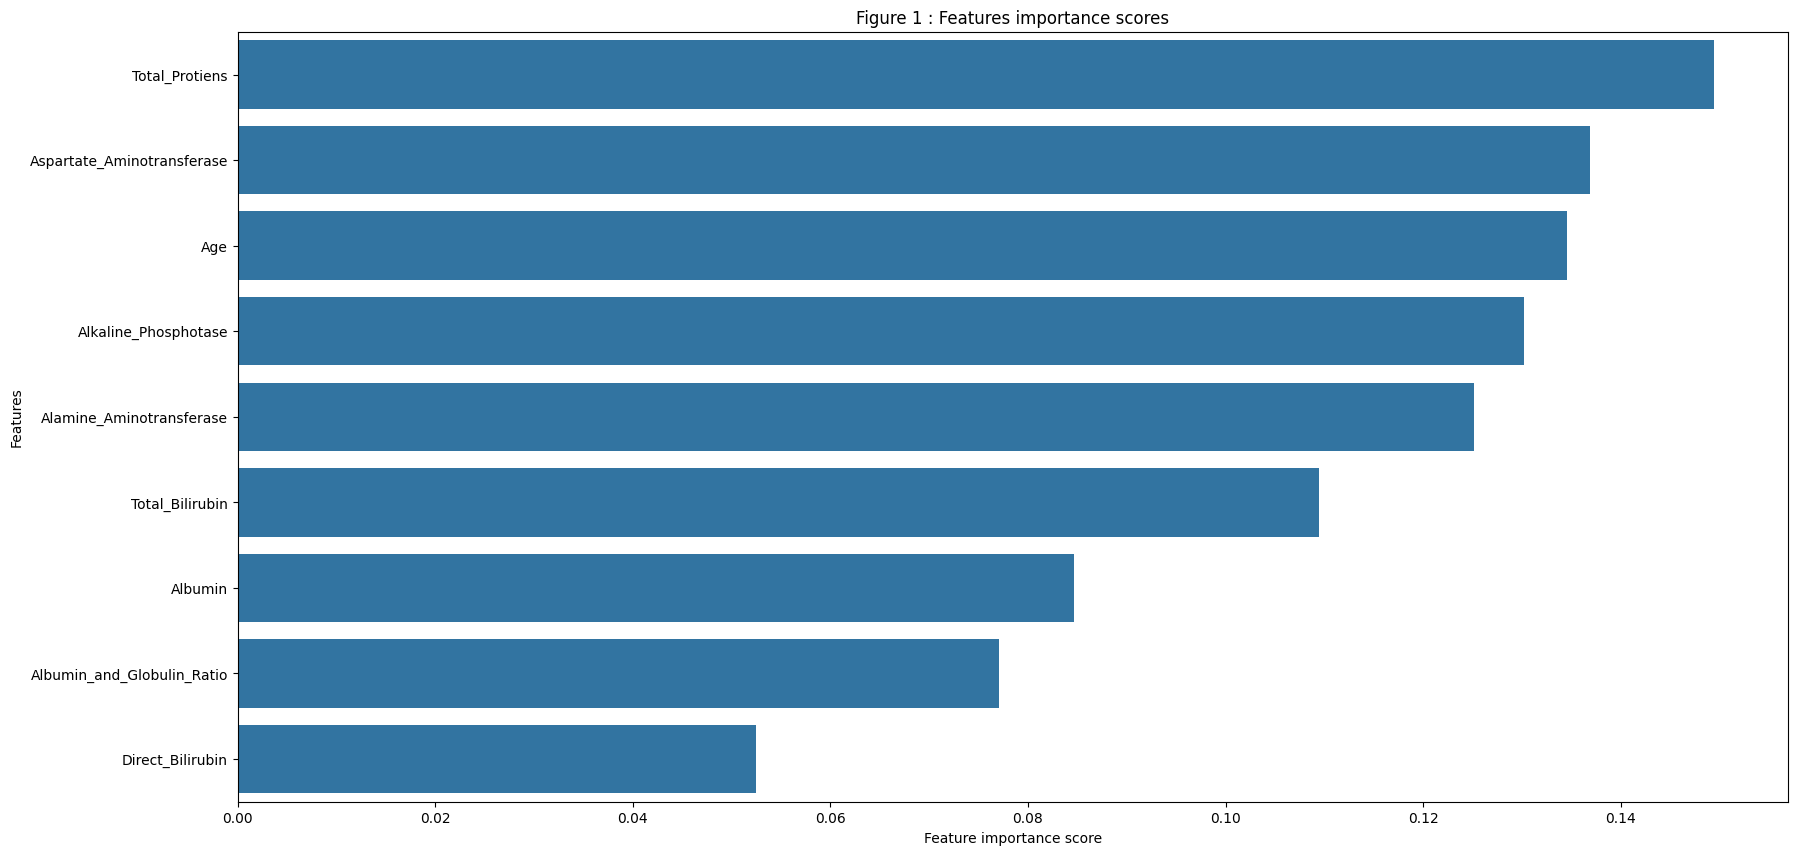

In [33]:
# Visualize features importance

fig, ax= plt.subplots(figsize=(20,10))

ax = sns.barplot(x=feature_scores, y=feature_scores.index, data=feature_imp_df)
ax.set_title("Figure 1 : Features importance scores")
ax.set_yticklabels(feature_scores.index)
ax.set_xlabel("Feature importance score")
ax.set_ylabel("Features")

plt.savefig("Figure1_features_importance_scores", dpi= 300)
plt.show()

### Feature importance visualization using Random Forest

The bar chart in figure 1, below shows the **Gini importance scores** of each feature, as computed by a Random Forest model. These scores indicate the contribution of each feature to reducing node impurity (e.g., Gini index) across all trees in the forest.

- **Most important features**:
  - `Total_Protiens`, `Aspartate_Aminotransferase`, and `Age` have the highest importance scores.
  - These features contribute the most to the model’s predictive performance.

- **Least important features**:
  - `Albumin_and_Globulin_Ratio` and `Direct_Bilirubin` show relatively low importance scores.

**Code summary**:
- Feature importances were extracted using `rf.feature_importances_`.
- A DataFrame was created and sorted to list features by importance.
- Seaborn's `barplot()` was used to generate a horizontal bar chart.
- The total computation time was very fast: **0.003 seconds**.

This analysis is useful for **feature selection** and understanding the model's decision-making process.


<Axes: >

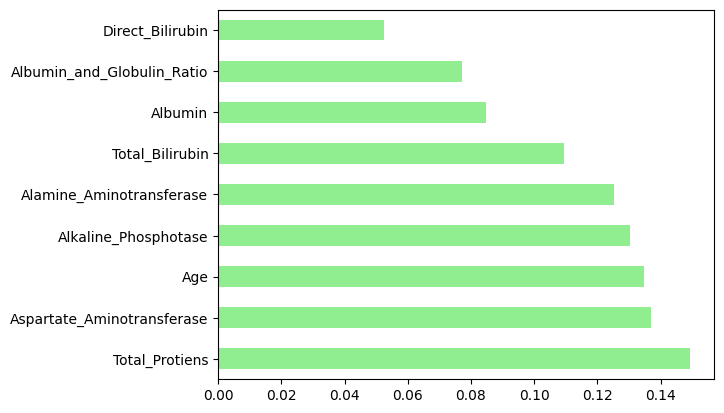

In [35]:
# Visualize features importance
feature_importances_series.plot(kind='barh', color= 'lightgreen')

We can observe the 3 most important features are 'Total_Protiens', 'Aspartate_Aminotransferase' and 'Age'. The least important feature is 'Direct_Bilirubin'.

[ENG]

EXERCISE 2 : MODEL COMPLEXITY, HYPERPARAMETERS AND GRID SEARCH

[FR]

EXERCICE 2 : COMPLEXITE DU MODELE, HYPERPARAMETRES ET GRID SEARCH

[ENG]

1. What is the underlying objective of a grid search?

[FR]

1. Quel est l’objectif que sous-tend une grid search ?

### Grid Search

Grid Search is an approach that allows us to optimize models by systematically selecting specific hyperparameters and exploring a range of values for them. 

For example, in a linear regression model (or any machine learning model), we may want to optimize the learning rate and the number of iterations. By choosing 3 values for each hyperparameter, we create a grid of 9 combinations (3 × 3) to evaluate.

We then determine the best hyperparameters by tracking the performance of each combination and selecting the one that yields the highest performance.

Grid Search can be implemented manually, or more conveniently, we can use the `GridSearchCV` function from the Scikit-Learn library, which automates the process.


[ENG]

2. Set up a random forest, based on the Gini index, with the following characteristics: min_samples_leaf= 1, min_samples_split= 2, random_state= 1

[FR]

2. Instanciez une forêt aléatoire, fondée sur l’indice de Gini, et avec les caractéristiques suivantes : min_samples_leaf= 1, min_samples_split= 2, random_state= 1

In [34]:
# Instantiate a Random Forest
rf2= RandomForestClassifier(criterion= 'gini', min_samples_leaf= 1, min_samples_split= 2, random_state=11)

[ENG]

3. Define two parameter vectors on which we will perform the Grid search. 'max_depth' : [2, 3, 4], and 'min_samples_leaf' : [0.12, 0.14,0.16, 0.18]= 1

[FR]

3. Définissez deux vecteurs de paramètres sur lesquels nous allons réaliser la Grid search. ’max_depth’ : [2, 3, 4], et ’min_samples_leaf’ : [0.12, 0.14,0.16, 0.18]

In [35]:
# Define parameters before setting the GridSearch up
params_dt= {'max_depth': [2, 3, 4], 'min_samples_leaf': [0.12, 0.14,0.16, 0.18]}


# Call Grid Search
grid_dt= GridSearchCV(estimator=rf2, param_grid= params_dt, cv=5, scoring= 'roc_auc')

# Fit the Grid to the dataset
grid_result = grid_dt.fit(X, y)

c:\Users\emmhu\anaconda3\envs\Bac_a_sable\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\emmhu\anaconda3\envs\Bac_a_sable\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\emmhu\anaconda3\envs\Bac_a_sable\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\emmhu\anaconda3\envs\Bac_a_sable\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d a

In [36]:
# Extract the best model parameters
best_model= grid_result.best_estimator_
print('The best model is :',best_model)

# Get the best cv score
best_score = grid_dt.best_score_
print(f"Best Cross-Validation Score: {best_score:.2f}")

The best model is : RandomForestClassifier(max_depth=3, min_samples_leaf=0.14, random_state=11)
Best Cross-Validation Score: 0.69


In [37]:
# Predict test set labels using the best model
y_pred_rf2 = grid_dt.predict(X_test)

# Evaluate Accuracy
print("Accuracy on Test Data:", accuracy_score(y_test, y_pred_rf2))

Accuracy on Test Data: 0.7485714285714286


In [38]:
# Evaluate AUC
y_probs_rf2= grid_dt.predict_proba(X_test)[:, 1]
auc_rf2 = roc_auc_score(y_test, y_probs_rf2)

print(f'The AUC score of grid_dt is : {auc_rf2:.2f}')

The AUC score of grid_dt is : 0.58


In [39]:
# Convert grid search results into a DataFrame
grid_results = pd.DataFrame(grid_dt.cv_results_)

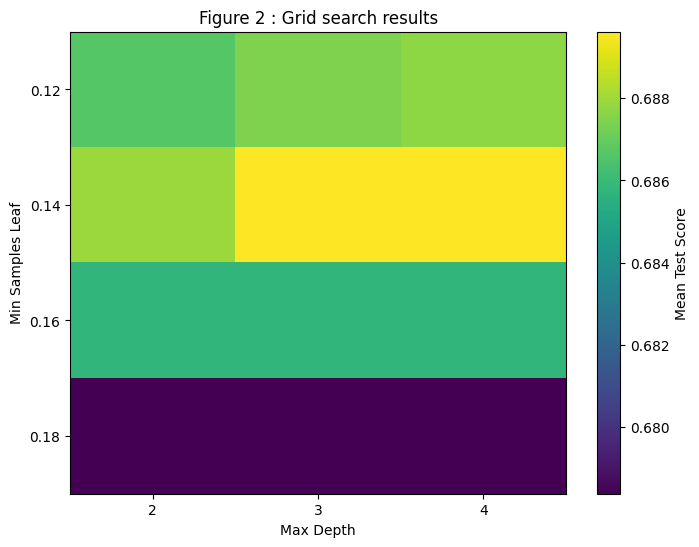

In [40]:
# Plot heatmap of mean test scores
pivot_table = grid_results.pivot_table(
    values="mean_test_score",
    index="param_min_samples_leaf",
    columns="param_max_depth"
)

plt.figure(figsize=(8, 6))
plt.title("Figure 2 : Grid search results")
plt.xlabel("Max Depth")
plt.ylabel("Min Samples Leaf")
plt.imshow(pivot_table, cmap="viridis", aspect= 'auto')
plt.colorbar(label="Mean Test Score")
plt.xticks(ticks=range(len(pivot_table.columns)), labels=pivot_table.columns)
plt.yticks(ticks=range(len(pivot_table.index)), labels=pivot_table.index)

plt.savefig("Figure2_grid_search_results.png", dpi= 300)
plt.show()

### Analysis of Grid Search Results

The figure shows the results of a grid search where two hyperparameters were tuned:

- **Max Depth** (x-axis): Controls the maximum depth of the decision tree.
- **Min Samples Leaf** (y-axis): Controls the minimum number of samples required to be at a leaf node.

Each color block represents the **mean test score** for a specific combination of `Max Depth` and `Min Samples Leaf`. A colorbar on the right indicates the scale of the mean test scores: lighter colors correspond to better performance (higher mean test scores), and darker colors correspond to lower performance.

**Observations:**
- The best performance (highest mean test score) is achieved around a `Max Depth` of 3 and a `Min Samples Leaf` of approximately 0.14.
- As `Min Samples Leaf` increases towards 0.18, performance decreases significantly, regardless of the `Max Depth`.
- `Max Depth` has a smaller influence on performance compared to `Min Samples Leaf` in this range — performance remains relatively stable across different depths but varies more clearly with different leaf sizes.

**Conclusion:**
- For this model, choosing a `Max Depth` of 3 and a `Min Samples Leaf` around 0.14 would likely provide the best balance between underfitting and overfitting based on the validation performance.


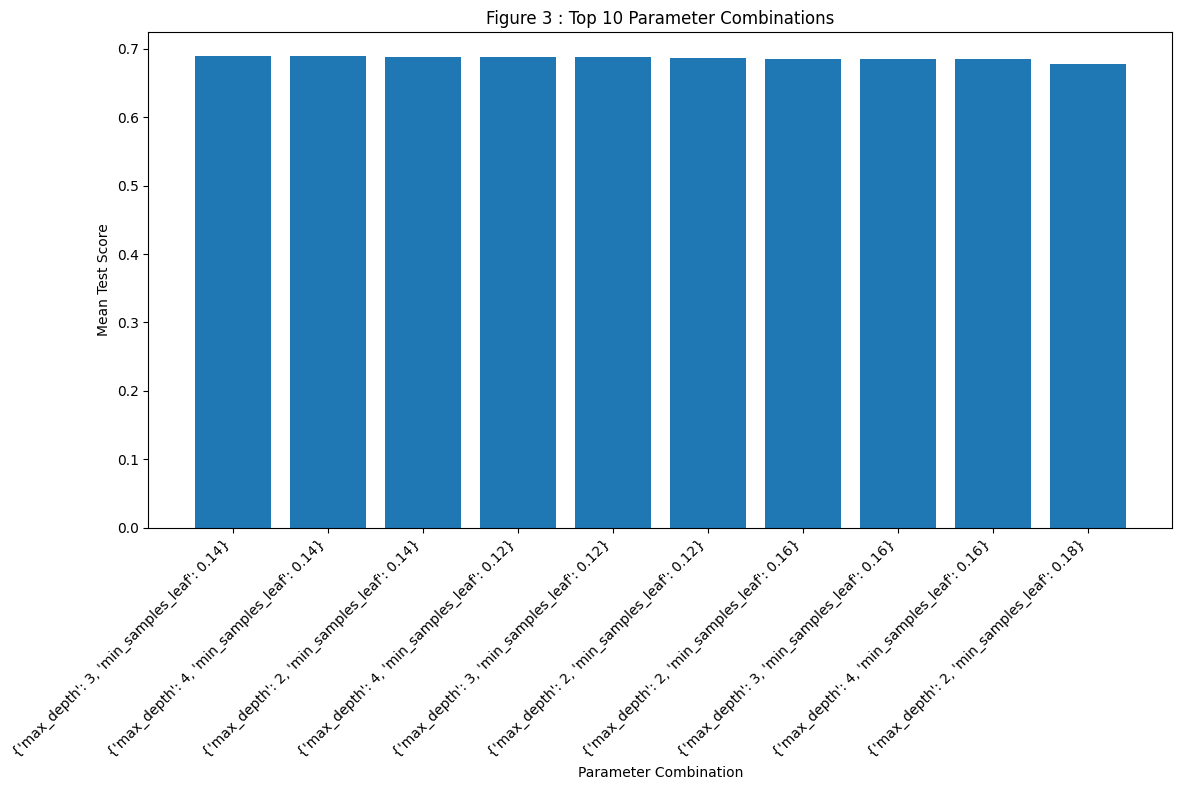

In [41]:
# Sort results by mean test score and select top 10
sorted_results = grid_results.sort_values(by='mean_test_score', ascending=False).head(10)

# Create the bar chart
plt.figure(figsize=(12, 8))
plt.bar(
    range(len(sorted_results)),
    sorted_results['mean_test_score'],
    tick_label=[str(param) for param in sorted_results['params']]
)

# Improve axis labels and formatting
plt.xticks(rotation=45, ha='right')
plt.title('Figure 3 : Top 10 Parameter Combinations')
plt.xlabel('Parameter Combination')
plt.ylabel('Mean Test Score')
plt.tight_layout()  # Ensure everything fits without overlapping

# Save and show
plt.savefig("Figure3_top_10_parameter_combinations.png", dpi=300)
plt.show()

### Analysis of Top 10 Parameter Combinations

The bar plot shows the Top 10 parameter combinations based on their Mean Test Score after performing a Grid Search. 

- **X-axis:** Parameter combinations of `max_depth` and `min_samples_leaf`.
- **Y-axis:** Mean Test Score (cross-validation performance metric).

#### Observations:
- The mean test scores are very close to each other, around 0.68–0.69, indicating that the model is relatively stable across these hyperparameter choices.
- The best results are obtained when `min_samples_leaf` is approximately **0.14** and `max_depth` is **between 2 and 4**.
- `min_samples_leaf` seems to have a slightly stronger impact on performance compared to `max_depth`.
- No major performance gains or losses are observed among the top combinations.

#### Conclusion:
- Choosing a `min_samples_leaf` around **0.14** and a `max_depth` between **2 and 4** appears optimal.
- The model may have reached a performance plateau with the current hyperparameter ranges.
- It might be useful to explore a broader range of values or tune additional hyperparameters to seek further improvements.
- This step is key for model optimization and ensures we get the best balance between bias and variance.

> **Note:** The x-axis labels are quite dense and could be simplified for better readability, such as by shortening the text to `"depth=3, leaf=0.14"`.